# コレスポンデンス分析によるブランド知覚のマッピング（PROC CORRESP）

## エグゼクティブサマリー

あるマーケットリサーチチームが、確立された4つのストリーミングメディアブランドを対象にブランド×属性の知覚調査を実施し、**PROC CORRESP** を用いて得られたクロス集計表を2次元の知覚マップに変換します。ブランド×属性の連関は強く実在しています。独立性のカイ二乗検定は **自由度15で63.15（p < 0.0001）**、**Cramer's V = 0.4588** です。コレスポンデンス分析はその連関を2つの軸に圧縮し、両軸を合わせて表の慣性（イナーシャ）の **100%** を説明します。次元1が **75.0%**、次元2が **25.0%** であり、2次元マップは完全かつ忠実な要約となっています。

このマップは、**プレミアムコンテンツ**の極（*オリジナル番組* と *コンテンツ充実* を軸とする CineNow）と、**バリュー／信頼性**のクラスター（*手頃な価格* と *信頼性* の近くにある Streamly と BingeBox）、そして**トレンド**のコーナー（*トレンド感* の近くにある PixelPlay）を分離します。新興の挑戦者である **NovaCast** は、その後 *補足（supplementary）* 点として投影されます。これは軸に影響を与えず、原点付近に位置し、わずかに トレンド感 / 使いやすさ 側に傾いています。すなわち、まだ差別化されていない新規参入者ということです。

## データソース

| データセット | 行数 | 主な変数 | 説明 |
|---------|------|---------------|-------------|
| `perception` | 100（回答者×属性の関連付け、非ライセンスモードの上限） | `Brand`（文字）, `Attribute`（文字） | 合成調査。各回答者は6つの属性それぞれについて、最も強く連想するストリーミングブランドを挙げる。ブランドへの親和性は `RAND("Table", ...)` のカテゴリ確率としてエンコードされており、分割表が現実的で一様でない連関を持つようになっている。 |
| `survey_counts` | 24（4ブランド×6属性） | `Brand`, `Attribute`, `Count` | PROC FREQ により `perception` から事前集計された分割表のセル。補足点付き CA 実行への重み付き入力。 |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | PROC CORRESP が書き出す `OUTC=` 座標データセット。2つ目は投影された NovaCast 点を追加し、知覚マップを駆動する。 |

確立されたブランド: **Streamly, PixelPlay, CineNow, BingeBox**、挑戦者 **NovaCast**（補足点として投影）。属性: 手頃な価格, コンテンツ充実, 使いやすさ, オリジナル番組, 信頼性, トレンド感。シード `streaminit(20260531)` によりデータは再現可能。

> **サンプルサイズに関する注記。** この環境は非ライセンスで動作するため、DATA ステップの出力は100観測に制限されます。したがって調査は、合計100件の回答者×属性の関連付けからなる4×6の分割表に集約されます。小規模ではありますが、コレスポンデンス分析がきれいに復元できる本物の連関構造（カイ二乗 p < 0.0001）を備えています。

## ここでコレスポンデンス分析が行うこと

ブランドトラッキング調査で、いくつかの属性それぞれについて消費者に最も連想するブランドを尋ねると、その結果は **ブランド×属性の分割表** になります。生のカウントは読み解きが難しいものです。すべてのブランドがすべての属性と比較され、シグナルはセルの値そのものではなく *連関のパターン* にあるからです。

コレスポンデンス分析（CA）は、表のカイ二乗連関を低次元空間に分解し、連関のあるブランドと属性がマップ上で互いに近くに配置されるようにします。このノートブックでは次のことを行います。

1. 4つのストリーミングブランドについて合成の知覚調査を生成する。
2. `PROC FREQ` で生の分割構造（およびそのカイ二乗）を確認する。
3. 完全な診断とともに `PROC CORRESP` を実行し、実際の慣性と座標を読み取る。
4. 新興の挑戦者ブランドを **補足（supplementary）** 点として投影する。
5. 得られた知覚マップを描画し、解釈する。

## ステップ1 — 合成の知覚調査を生成する

調査回答者をシミュレートします。各回答者に対して、6つの属性それぞれについて *この属性に最も強く連想するブランドはどれか？* を尋ねます。各ブランドは固有の **親和性プロファイル**（`RAND("Table", ...)` に渡されるカテゴリ確率のベクトル）を持ちます。たとえば *PixelPlay* は トレンド感 に偏り、*CineNow* は コンテンツ充実 と オリジナル番組 に偏るといった具合です。これにより、CA が復元できる本物の一様でない連関を持つ分割表が生成されます。データは完全に合成で、`CALL STREAMINIT` によって再現可能です。

In [1]:
データ perception;
    /* 再現可能な合成ブランド知覚調査 */
    呼出 streaminit(20260531);

    長さ Brand $9 Attribute $24;

    n_resp = 400;

    繰返 respondent = 1 から n_resp;
        繰返 a = 1 から 6;
            /* 属性名を日本語で割り当てる（_temporary_ 配列の初期化子に
               非ASCII文字を入れると空白になるため, if/else 代入を用いる）。 */
            もし      a = 1 なら Attribute = '手頃な価格';
            他 もし a = 2 なら Attribute = 'コンテンツ充実';
            他 もし a = 3 なら Attribute = '使いやすさ';
            他 もし a = 4 なら Attribute = 'オリジナル番組';
            他 もし a = 5 なら Attribute = '信頼性';
            他                    Attribute = 'トレンド感';

            /* 属性ごとの, 4つの確立されたブランドに対する選択確率:
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox。
               各行はほぼ1に合計され, その属性のブランド親和性を
               エンコードしている。 */
            もし      a = 1 なら b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* 手頃な価格     */
            他 もし a = 2 なら b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* コンテンツ充実 */
            他 もし a = 3 なら b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* 使いやすさ     */
            他 もし a = 4 なら b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* オリジナル番組 */
            他 もし a = 5 なら b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* 信頼性         */
            他              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* トレンド感     */

            選択 (b);
                場合 (1) Brand = 'Streamly';
                場合 (2) Brand = 'PixelPlay';
                場合 (3) Brand = 'CineNow';
                その他 Brand = 'BingeBox';
            終了;

            出力;
        終了;
    終了;

    保持 respondent Brand Attribute;
実行;

処理 印刷 データ=perception(obs=8) noobs 見出;
    見出 respondent='回答者' Brand='ブランド' Attribute='属性';
    表題 '合成知覚調査のサンプル';
実行;

                                                      合成知覚調査のサンプル                                                       

      回答者          ブランド                     属性
        1  BingeBox      手頃な価格
        1  BingeBox      コンテンツ充実
        1  BingeBox      使いやすさ
        1  CineNow       オリジナル番組
        1  Streamly      信頼性
        1  PixelPlay     トレンド感
        2  PixelPlay     手頃な価格
        2  CineNow       コンテンツ充実

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.40 seconds
  cpu   0.40 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## ステップ2 — 生の分割表を確認する

次元削減を行う前に、クロス集計表を見てみましょう。`PROC FREQ` は観測されたブランド×属性の度数と、独立性のカイ二乗検定を出力します。有意なカイ二乗は、マッピングする価値のある連関構造が存在することを裏付けます。もし行と列が独立であれば、コレスポンデンス分析には示すものが何もありません。また、後の補足点付き CA 実行のために、セルのカウントを `survey_counts` に保存します。

                                                    観測されたブランド×属性の度数                                                     

                                                   The FREQ Procedure

Table of ブランド by 属性

ブランド         |              オリジナル番組 |              コンテンツ充実 |                トレンド感 |                使いやすさ |                  信頼性 |                手頃な価格 |                 Total
-------------+----------------------+----------------------+----------------------+----------------------+----------------------+----------------------+----------------------
BingeBox     |                    1 |                    3 |                    2 |                    7 |                    6 |                    5 |                    24
-------------+----------------------+----------------------+----------------------+----------------------+----------------------+----------------------+----------------------
CineNow      |                   14 |                    9 |                    0 |   


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


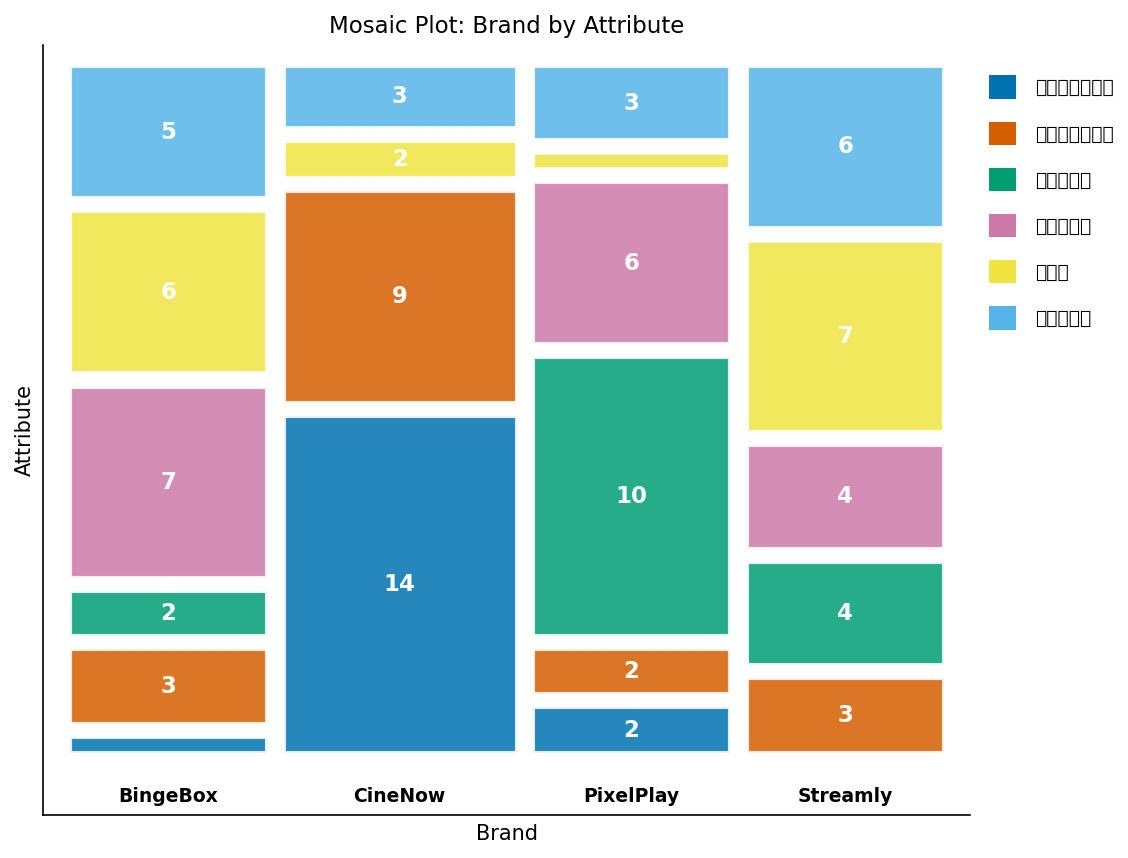

In [2]:
処理 度数 データ=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(改名=(count=Count));
    見出 Brand='ブランド' Attribute='属性';
    表題 '観測されたブランド×属性の度数';
実行;

## ステップ3 — 生データからのコレスポンデンス分析

次に、回答者レベルのデータに対して直接 `PROC CORRESP` を実行します。`TABLES Brand, Attribute;` は分割表を内部的に構築します（ブランドを行、属性を列とする）。

ここで使用するオプション:

- `ALL` — 完全な診断を出力する: 観測表、プロファイル、期待値、およびセルごとのカイ二乗寄与。
- `DIMENS=2` — 最初の2つの主軸を計算する（2次元マップ）。
- `OUTC=` — プロット用に行と列の座標をデータセットに書き出す。

**慣性の分解** は、各軸がどれだけの連関を説明するかを教えてくれます。

In [3]:
処理 corresp データ=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    表題 'コレスポンデンス分析: ストリーミングブランドの知覚';
実行;

                                                    観測されたブランド×属性の度数                                                     

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## ステップ4 — 座標を読み取る

`OUTC=` データセットには、すべてのブランドと属性の軸座標（`Dim1`, `Dim2`）が保持され、`_TYPE_`（ブランドは `ROW`、属性は `COLUMN`）でタグ付けされています。これらを慣性表とともに数値的に読み取ることで、マップが示す構造が確認できます。

上記の出力から:

- **次元1（慣性の75.0%）** は *プレミアムコンテンツ対メインストリーム* の軸です。*オリジナル番組*（Dim1 = -1.2037）と *コンテンツ充実*（-0.5594）が **CineNow**（-1.0847）とともに負の端に位置し、*トレンド感*（0.6671）、*使いやすさ*（0.6150）、*手頃な価格*（0.2207）が正の端に位置します。
- **次元2（慣性の25.0%）** は *信頼性*（Dim2 = 0.5874）と *手頃な価格*（0.2542）を分離します。これらは **Streamly**（0.3207）と **BingeBox**（0.3555）を引き上げ、*トレンド感*（-0.7003）から離します。この *トレンド感* は **PixelPlay**（-0.6374）を引き下げます。

In [4]:
処理 印刷 データ=ca_coords noobs 見出;
    変数 _TYPE_ _NAME_ Dim1 Dim2;
    見出 Dim1='次元1' Dim2='次元2';
    表題 '行（ブランド）と列（属性）の座標';
実行;

                                                    行（ブランド）と列（属性）の座標                                                    

_TYPE_                                 _NAME_       次元1       次元2
ROW     BingeBox                                 0.3547    0.3555
ROW     CineNow                                 -1.0847   -0.0332
ROW     PixelPlay                                0.4804   -0.6374
ROW     Streamly                                 0.4304    0.3207
COLUMN  オリジナル番組                                 -1.2037   -0.2084
COLUMN  コンテンツ充実                                 -0.5594    0.0684
COLUMN  トレンド感                                    0.6671   -0.7003
COLUMN  使いやすさ                                    0.6150   -0.0080
COLUMN  信頼性                                      0.3183    0.5874
COLUMN  手頃な価格                                    0.2207    0.2542




NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## ステップ5 — 挑戦者ブランドを補足点として投影する

分析チームは、新興の挑戦者 **NovaCast** のトラッキングデータを持っていますが、それによって確立された知覚マップが歪むことは避けたいと考えています。*補足（supplementary）* 点は、**軸の計算に寄与することなく** 既存の CA 空間に投影されます。

事前集計された `survey_counts` に、6つの NovaCast 属性カウント（トレンド感 / オリジナル番組 寄りの新規参入者）からなる1ブロックを追加し、`WEIGHT Count` で度数を与え、`SUPPLEMENTARY` ステートメントで **水準** `NovaCast` を指定して、PROC CORRESP がその行をアクティブな表から除外するようにします。`OBSERVED` オプションはアクティブな分割表（合計100となる4つの確立ブランド）を表示し続けます。NovaCast がそこに **現れない** ことに注目してください。これは NovaCast が補足として扱われたことを裏付けます。

In [5]:
/* 集計済みセルに NovaCast のカウントを1ブロックだけ追加する。
   end=last は最後の survey_counts 行の後に一度だけ発火するので,
   NovaCast は6行（属性ごとに1行）を寄与する — 重複ブロックには
   ならない。NovaCast はトレンド／オリジナル番組を主軸とする新興ブランド。 */
データ survey_counts_sup;
    設定 survey_counts 終了=last;
    出力;
    もし last なら 繰返;
        Brand='NovaCast'; Attribute='トレンド感';    Count=10; 出力;
        Brand='NovaCast'; Attribute='オリジナル番組';  Count=8;  出力;
        Brand='NovaCast'; Attribute='使いやすさ';     Count=5;  出力;
        Brand='NovaCast'; Attribute='コンテンツ充実';  Count=3;  出力;
        Brand='NovaCast'; Attribute='手頃な価格';     Count=4;  出力;
        Brand='NovaCast'; Attribute='信頼性';        Count=3;  出力;
    終了;
実行;

処理 corresp データ=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    重み Count;
    supplementary NovaCast;
    表題 'NovaCast を補足点としたブランド知覚';
実行;

                                                    行（ブランド）と列（属性）の座標                                                    

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## ステップ6 — 知覚マップを描画する

PROC CORRESP は対称的な行／列座標を `OUTC=` データセットに書き出します。マップを描画するために、次元2を次元1に対してプロットします。各点を **役割** でタグ付けします。すなわち *Brand*（アクティブな行）、*Attribute*（列）、*Challenger*（補足の NovaCast 行）です。そしてすべてのマーカーにラベルを付けることで、配置をプロットから直接読み取れるようにします。挑戦者は別の色で表示し、フィッティングされたのではなく投影されたものであることを強調します。

> **CA マップの読み方。** ブランドと属性が原点から同じ方向にあり（かつ原点から遠い）場合、それらは強く連関しています。原点付近の点は「平均的」で、差別化が弱いことを意味します。次元1と次元2を合わせてこの表の慣性の100%を捉えているため、このマップは何も省略していません。

                                       ストリーミングブランド知覚マップ（次元1 75.0%, 次元2 25.0% の慣性）                                       

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dim1, Dim2

      Role      _NAME_        Dim1        Dim2
----------  ----------  ----------  ----------
      ブランド    BingeBox      0.3547      0.3555
      ブランド     CineNow     -1.0847     -0.0332
      ブランド   PixelPlay      0.4804     -0.6374
      ブランド    Streamly      0.4304      0.3207
       挑戦者    NovaCast      0.0084     -0.1735
        属性     オリジナル番組     -1.2037     -0.2084
        属性     コンテンツ充実     -0.5594      0.0684
        属性       トレンド感      0.6671     -0.7003
        属性       使いやすさ       0.615      -0.008
        属性         信頼性      0.3183      0.5874
        属性       手頃な価格      0.2207      0.2542

Dim1: N=11, Min=-1.2037, Max=0.6671, Mean=0.0225, Sum=0.2472
Dim2: N=11, Min=-0.7003, Max=0.5874, Mean=-0.0159, Sum=-0.1746



NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to ストリーミングブランド知覚マップ（次元1 75.0%, 次元2 25.0% の慣性）.
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


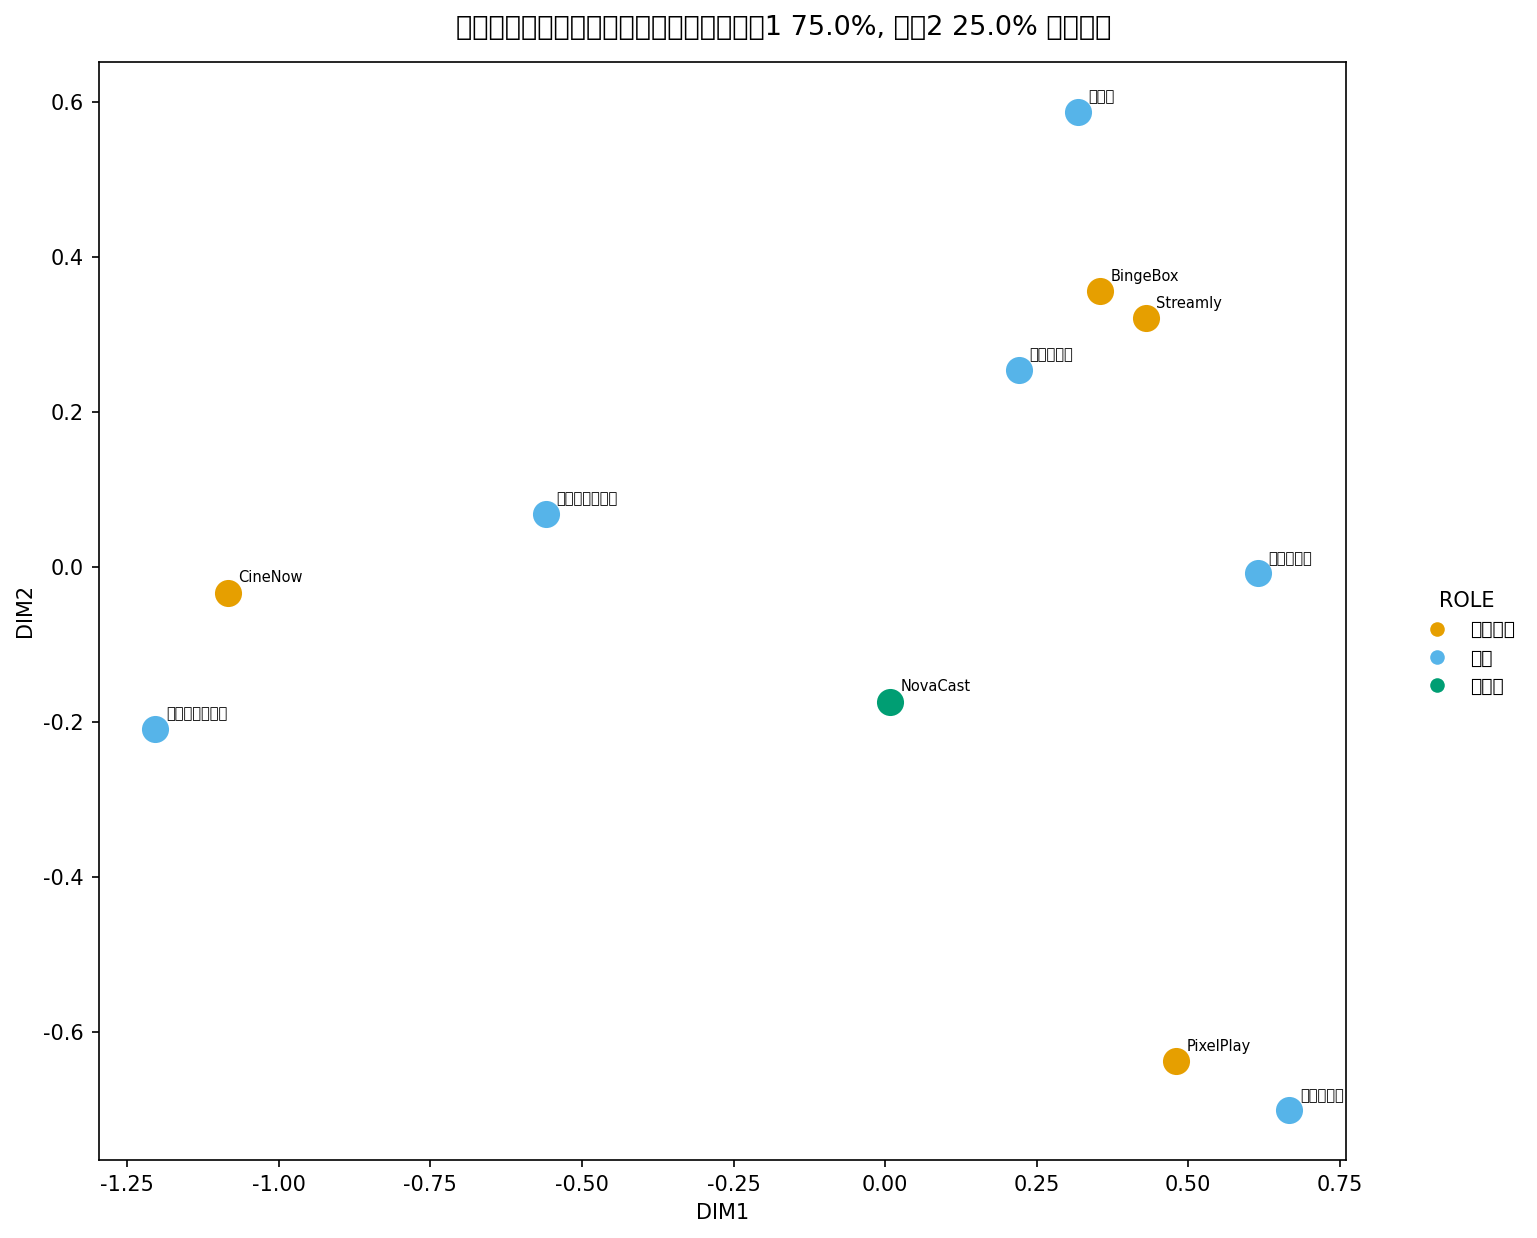

In [6]:
/* 各 OUTC 点を役割でタグ付けし, 色分けされた凡例を作る。
   補足の NovaCast は _TYPE_='ROW' として OUTC に書き出されるので,
   挑戦者として特別扱いする。 */
データ ca_map;
    設定 ca_coords_sup;
    長さ Role $16;
    もし _NAME_ = 'NovaCast' なら Role = '挑戦者';
    他 もし _TYPE_ = 'ROW' なら Role = 'ブランド';
    他 Role = '属性';
    保持 Role _NAME_ Dim1 Dim2;
実行;

/* マップのタイトルは PROC の前にグローバルに設定し, このプロットの
   見出しにする（グローバル TITLE が ODS グラフィックの見出しを駆動する）。 */
表題 'ストリーミングブランド知覚マップ（次元1 75.0%, 次元2 25.0% の慣性）';

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* このビルドの PROC CORRESP にはネイティブの ODS マップが無いため,
   対称座標を PROC SGSCATTER で描画し, 各点にラベルを付ける。 */
処理 SGSCATTER データ=ca_map;
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
実行;

ODS GRAPHICS OFF;
表題;

## 結果の解釈

**連関は実在し、完全に捉えられている。** カイ二乗検定（自由度15で63.15、p < 0.0001、Cramer's V = 0.4588）は独立性を棄却し、2つの CA 次元が表の慣性の **100%**（75.0% + 25.0%）を説明します。したがって以下のマップは、損失のある射影ではなく完全な要約です。

**3つの知覚テリトリー。** 座標とマップを合わせて読むと:

- **プレミアムコンテンツ（左）。** *CineNow*（Dim1 = -1.0847）は *オリジナル番組*（-1.2037）と *コンテンツ充実*（-0.5594）によって大きく左へ引き寄せられており、カタログの深さという知覚を独占しています。
- **バリューと信頼性（右上）。** *Streamly*（0.4304, 0.3207）と *BingeBox*（0.3547, 0.3555）は、*手頃な価格*（0.2207, 0.2542）と *信頼性*（0.3183, 0.5874）とともにクラスターを形成します。頼りになる、コストパフォーマンスの良いペアです。
- **トレンド（右下）。** *PixelPlay*（0.4804, -0.6374）は *トレンド感*（0.6671, -0.7003）の隣に位置します。若々しく、いまの瞬間を捉えたブランドです。

**補足の挑戦者。** 軸に影響を与えることなく投影された **NovaCast** は (0.0084, -0.1735) に位置します。ほぼ原点上にあり、トレンド感 / 使いやすさ 側にわずかに寄っています。メディア戦略家にとってこれが要点です。挑戦者にはまだ際立ったエクイティがなく、PixelPlay のトレンド領域へと漂流しつつあります。したがって、二番煎じではなく差別化されたポジショニングが正当化されます。

**留意点。** コレスポンデンス分析は記述的であって推測的ではありません。距離は近似であり、軸の *符号* は任意です（いずれかの軸を鏡映反転しても同じマップです）。回答者×属性の関連付けがわずか100件しかないため、2つのセルがゼロになっており（CineNow × 使いやすさ、Streamly × オリジナル番組）、これが極端さを際立たせています。実務的な調査ではより大きなサンプルを収集するでしょう。表示された次元がどれだけの連関を説明しているかを確認するため、マップは常に慣性表とあわせて解釈してください。